# Carril 2.5 (post-experimento) - EVT/CVaR + *position sizing*: resumen narrativo y evidencia visual

**Alcance:** consolidar la ejecución del **carril del riesgo** sobre los 32 estudios `*_frozen_20260517T134241Z` (*frozen replay* del Exp2 documentado en `05_resumen_greedy_contextual.ipynb`). Para cada rama se aplica la política `evt_cvar` y dos políticas de *sizing* (`fixed_control`, `vol_target`) sin reentrenamiento, leyendo predicciones congeladas en disco.

**Pregunta central:** ¿Filtrar por EVT/CVaR mejora la admisibilidad económica del campeón greedy en términos de **Sharpe agregado** y *drawdown* sin destruir cobertura?

**Métrica primaria:** Sharpe agregado *out-of-sample* del brazo control (`ctrl_sharpe`) y filtrado (`filt_sharpe`) y su delta. **MaxDD primario:** mediana del MaxDD entre *outer folds* (`*_max_drawdown_fold_median`).

El gate `execution_risk_two_arm_acceptance` se documenta en la **sección 2** como lectura diagnóstica contractual. La **sección 8** reporta el DSR recalculado del brazo filtrado (N total por celda); el DSR del JSON del gate se conserva solo como diagnóstico local del paso 2.5, no como métrica narrativa de cierre.

**Sello (`frozen_stamp`):** `20260517T134241Z` (subdirectorio de auditoría: `frozen_20260517T134241Z_audit_v2`).

**Insumos:** un `post_experiment_risk_lane_report.json` por rama bajo `reports/validation/experiments/greedy_*_frozen_20260517T134241Z/execution_risk/post_experiment/frozen_20260517T134241Z_audit_v2/`.

**Productos:** tablas CSV y figuras PNG bajo `reports/figures/exp_synthesis/post_experiment/` (lista exhaustiva en la sección 9).


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.options.display.max_columns = 60
pd.options.display.max_rows = 200
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

COLUMNAS_ES = {
    'symbol': 'simbolo',
    'method': 'metodo',
    'family': 'familia',
    'study_id': 'id_estudio',
    'is_accepted': 'aceptado',
    'ctrl_max_drawdown_fold_median': 'maxdd_control_mediana_fold',
    'filt_max_drawdown_fold_median': 'maxdd_filtrado_mediana_fold',
    'delta_maxdd_fold': 'delta_maxdd_fold',
    'ctrl_sharpe': 'sharpe_control',
    'filt_sharpe': 'sharpe_filtrado',
    'delta_sharpe': 'delta_sharpe',
    'fixed_control_sharpe': 'sharpe_fixed_control',
    'vol_target_sharpe': 'sharpe_vol_target',
    'delta_vt_minus_fc_sharpe': 'delta_vt_menos_fc_sharpe',
    'blocked_trade_rate': 'tasa_bloqueo',
    'arch_pack': 'arquitectura_paquete',
    'observed_sr': 'sharpe_observado',
    'n_trials_total': 'n_trials_total',
    'dsr_exact': 'dsr_filtrado',
    'is_significant_dsr': 'dsr_supera_0_95',
}


def _nombre_columna_es(nombre: str) -> str:
    return COLUMNAS_ES.get(nombre, nombre)


def a_es(frame: pd.DataFrame | pd.Series) -> pd.DataFrame:
    if isinstance(frame, pd.Series):
        frame = frame.to_frame(name=frame.name)
    vista = frame.copy()
    vista.columns = [_nombre_columna_es(str(col)) for col in vista.columns]
    if vista.index.name:
        vista.index.name = _nombre_columna_es(str(vista.index.name))
    if isinstance(vista.index, pd.MultiIndex):
        vista.index = vista.index.set_names([
            _nombre_columna_es(str(name)) if name is not None else name
            for name in vista.index.names
        ])
    return vista


def display_es(frame: pd.DataFrame | pd.Series) -> None:
    display(a_es(frame))


def locate_repo_root(start: Path | None = None) -> Path:
    root = (start or Path.cwd()).resolve()
    while root != root.parent and not (root / 'src').exists():
        root = root.parent
    if not (root / 'src').exists():
        raise FileNotFoundError('No se encontró la raíz del repo (carpeta src/).')
    return root


ROOT = locate_repo_root()
EVIDENCE_DIR = ROOT / 'evidence_utils'
if str(EVIDENCE_DIR) not in sys.path:
    sys.path.insert(0, str(EVIDENCE_DIR))

from phase_summaries import (
    FROZEN_STAMP_DEFAULT,
    POST_EXPERIMENT_SUBDIR_DEFAULT,
    load_dsr_exact_post_experiment_table,
    load_post_experiment_summary,
)

REPORT_ROOT = ROOT / 'reports' / 'validation' / 'experiments'
FIG_DIR = ROOT / 'reports' / 'figures' / 'exp_synthesis' / 'post_experiment'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(
    f'Carril 2.5 | stamp={FROZEN_STAMP_DEFAULT} | '
    f'auditoria={POST_EXPERIMENT_SUBDIR_DEFAULT}'
)


Carril 2.5 | stamp=20260517T134241Z | auditoria=post_experiment/frozen_20260517T134241Z_audit_v2


## 1. Carga y vista preliminar de los 32 reportes

Cada fila es una rama *frozen*. La vista preliminar muestra **Sharpe agregado** del brazo control y del brazo filtrado, su delta y la **mediana del MaxDD entre folds** para ambos brazos. La columna `aceptado` (`is_accepted`) resume el gate contractual; el desglose por sub-condiciones está en la **sección 2**. Para filtrar ramas aceptadas o ordenar por delta Sharpe, usar esta tabla (no hay shortlist aparte).


In [2]:
post = load_post_experiment_summary(REPORT_ROOT)
post.to_csv(FIG_DIR / 'post_experiment_raw.csv', index=False)
print(f'N de ramas leídas: {len(post)}')

preview_cols = [
    'symbol', 'method', 'family', 'is_accepted',
    'ctrl_sharpe', 'filt_sharpe', 'delta_sharpe',
    'ctrl_max_drawdown_fold_median', 'filt_max_drawdown_fold_median',
    'blocked_trade_rate',
]
display_es(post[preview_cols].head(10).round(4))

N de ramas leídas: 32


,simbolo,metodo,familia,aceptado,sharpe_control,sharpe_filtrado,delta_sharpe,maxdd_control_mediana_fold,maxdd_filtrado_mediana_fold,tasa_bloqueo
0,BNBUSDT,fixed_horizon,residual_hybrid,True,0.0542,0.0542,0.0000,-0.5547,-0.5547,0.0000
1,BNBUSDT,fixed_horizon,residual_hybrid,True,0.0550,0.0550,0.0000,-0.4937,-0.4937,0.0000
2,BNBUSDT,trend_scanning,residual_hybrid,True,0.0638,0.0606,-0.0032,-0.9079,-0.8944,0.0526
3,BNBUSDT,trend_scanning,residual_hybrid,True,0.0805,0.0742,-0.0063,-0.9127,-0.9051,0.0526
4,BNBUSDT,triple_barrier,residual_hybrid,False,0.0073,0.0063,-0.0011,-0.3492,-0.3492,0.0153
5,BNBUSDT,triple_barrier,residual_hybrid,True,0.0269,0.0257,-0.0012,-0.3464,-0.3464,0.0189
6,BTCUSDT,fixed_horizon,residual_hybrid,False,0.0028,0.0028,0.0000,-0.4818,-0.4818,0.0000
7,BTCUSDT,fixed_horizon,residual_hybrid,True,0.0261,0.0261,0.0000,-0.3975,-0.3975,0.0000
8,BTCUSDT,trend_scanning,lstm,True,0.0535,0.0520,-0.0015,-0.8656,-0.8589,0.0202
9,BTCUSDT,trend_scanning,xgboost,False,0.0148,0.0131,-0.0017,-0.8656,-0.8656,0.0206


## 2. Resultado del *gate* `execution_risk_two_arm_acceptance` (lectura diagnóstica)

El *gate* del contrato del Exp2.5 combina tres condiciones:

- `reduces_drawdown_or_cvar` (defensivo, operador OR): el filtro reduce *drawdown* **o** CVaR realizada.
- `retains_significant_dsr`: el DSR del brazo filtrado en el JSON supera 0.95 (`DEFAULT_DSR_PROMOTION_THRESHOLD`). **No es la métrica de multiplicidad defendible**; la lectura con N total por celda está en la **sección 8**.
- `same_outer_folds_as_model_selection`: invariante de identidad temporal (debe pasar siempre).

**`is_accepted = True`** requiere las tres condiciones. Esta sección **no es la lectura primaria** del paso (Sharpe y MaxDD por fold en las secciones 3 y 7); aquí solo se reporta el desglose del gate como diagnóstico contractual.


Conteos de aceptación


,n_ramas
aceptado_si,14
aceptado_no,18
defensivo_pasa,32
dsr_pasa,14
mismos_folds_pasa,32


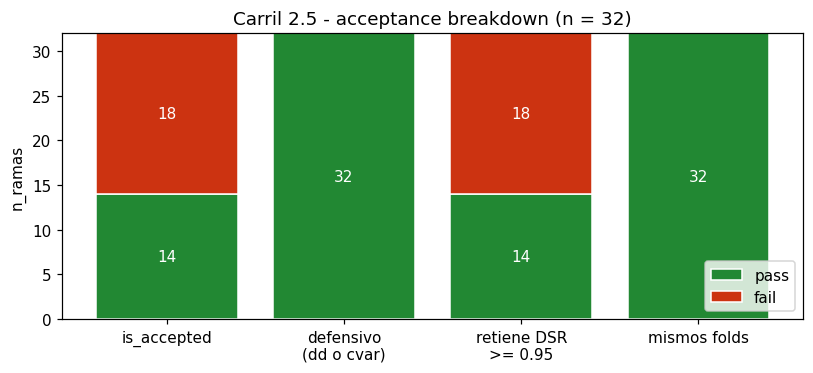

In [3]:
accept_counts = {
    'aceptado_si': int((post['is_accepted'] == True).sum()),
    'aceptado_no': int((post['is_accepted'] == False).sum()),
    'defensivo_pasa': int((post['gate_defensive_passed'] == True).sum()),
    'dsr_pasa': int((post['gate_dsr_passed'] == True).sum()),
    'mismos_folds_pasa': int((post['gate_same_folds_passed'] == True).sum()),
}
pd.DataFrame([accept_counts]).to_csv(FIG_DIR / 'post_experiment_acceptance_counts.csv', index=False)
print('Conteos de aceptación')
display(pd.DataFrame([accept_counts]).T.rename(columns={0: 'n_ramas'}))

fig, ax = plt.subplots(figsize=(7.5, 3.5))
labels = ['is_accepted', 'defensivo\n(dd o cvar)', 'retiene DSR\n>= 0.95', 'mismos folds']
pass_values = [accept_counts['aceptado_si'], accept_counts['defensivo_pasa'],
               accept_counts['dsr_pasa'], accept_counts['mismos_folds_pasa']]
fail_values = [len(post) - v for v in pass_values]
x = np.arange(len(labels))
ax.bar(x, pass_values, color='#228833', label='pass', edgecolor='white')
ax.bar(x, fail_values, bottom=pass_values, color='#CC3311', label='fail', edgecolor='white')
for i, (p, f) in enumerate(zip(pass_values, fail_values)):
    ax.text(i, p / 2, str(p), ha='center', va='center', color='white', fontsize=10)
    if f > 0:
        ax.text(i, p + f / 2, str(f), ha='center', va='center', color='white', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('n_ramas')
ax.set_title(f'Carril 2.5 - acceptance breakdown (n = {len(post)})')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'post_experiment_acceptance_breakdown.png')
plt.show()

## 3. Efecto del filtro EVT/CVaR sobre el Sharpe agregado

Comparativa **Sharpe brazo filtrado vs. brazo control** por rama y distribución del delta. Un delta positivo indica que el filtro mejora el Sharpe agregado; negativo indica que lo deteriora.


Estadísticos del delta_sharpe (filtrado - control)


,valor
n_ramas,32.000000
n_mejoradas,4.000000
n_empeoradas,10.000000
n_neutrales,18.000000
media_delta,-0.000488
mediana_delta,0.000000
minimo_delta,-0.006317
maximo_delta,0.002294


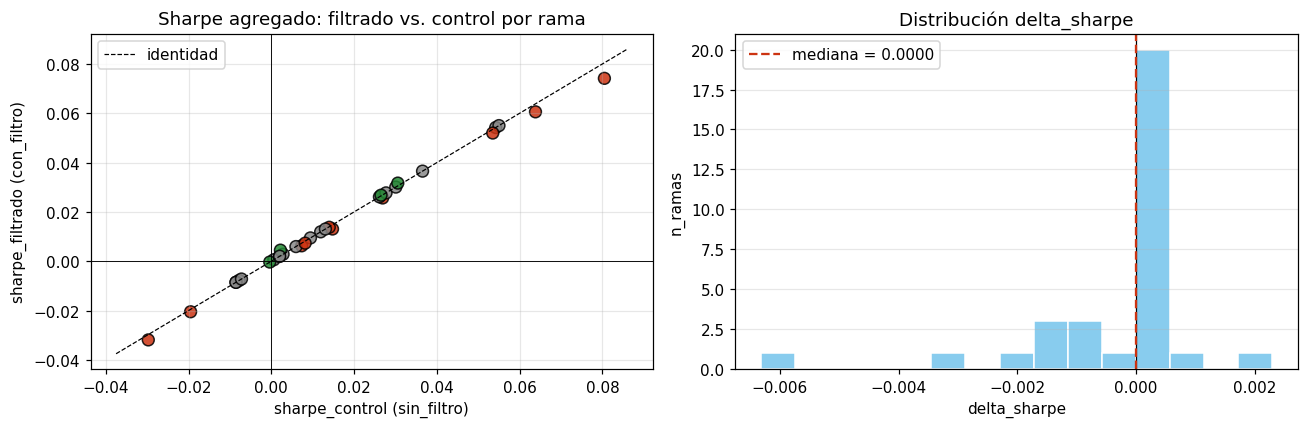

In [4]:
post_delta = post.dropna(subset=['delta_sharpe']).copy()
post_delta['delta_sharpe'] = post_delta['delta_sharpe'].astype(float)
post_delta['ctrl_sharpe'] = post_delta['ctrl_sharpe'].astype(float)
post_delta['filt_sharpe'] = post_delta['filt_sharpe'].astype(float)

delta_stats = {
    'n_ramas': int(len(post_delta)),
    'n_mejoradas': int((post_delta['delta_sharpe'] > 0).sum()),
    'n_empeoradas': int((post_delta['delta_sharpe'] < 0).sum()),
    'n_neutrales': int((post_delta['delta_sharpe'] == 0).sum()),
    'media_delta': float(post_delta['delta_sharpe'].mean()),
    'mediana_delta': float(post_delta['delta_sharpe'].median()),
    'minimo_delta': float(post_delta['delta_sharpe'].min()),
    'maximo_delta': float(post_delta['delta_sharpe'].max()),
}
pd.DataFrame([delta_stats]).to_csv(FIG_DIR / 'post_experiment_delta_sharpe_stats.csv', index=False)
print('Estadísticos del delta_sharpe (filtrado - control)')
display(pd.DataFrame([delta_stats]).T.rename(columns={0: 'valor'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.scatter(post_delta['ctrl_sharpe'], post_delta['filt_sharpe'],
           c=['#228833' if v > 0 else '#CC3311' if v < 0 else '#888888'
              for v in post_delta['delta_sharpe']],
           edgecolor='black', s=60, alpha=0.85)
lim_lo = float(min(post_delta['ctrl_sharpe'].min(), post_delta['filt_sharpe'].min(), 0))
lim_hi = float(max(post_delta['ctrl_sharpe'].max(), post_delta['filt_sharpe'].max(), 0.01))
pad = max((lim_hi - lim_lo) * 0.05, 0.005)
ax.plot([lim_lo - pad, lim_hi + pad], [lim_lo - pad, lim_hi + pad],
        color='black', linewidth=0.8, linestyle='--', label='identidad')
ax.axhline(0, color='black', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('sharpe_control (sin_filtro)')
ax.set_ylabel('sharpe_filtrado (con_filtro)')
ax.set_title('Sharpe agregado: filtrado vs. control por rama')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(post_delta['delta_sharpe'].values, bins=15,
        color='#88CCEE', edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(post_delta['delta_sharpe'].median(), color='#CC3311', linestyle='--',
           label=f'mediana = {post_delta["delta_sharpe"].median():.4f}')
ax.set_xlabel('delta_sharpe')
ax.set_ylabel('n_ramas')
ax.set_title('Distribución delta_sharpe')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'post_experiment_delta_sharpe.png')
plt.show()

## 4. Bloqueo del filtro (`blocked_trade_rate`) y cobertura

Mide la fracción de *trades* bloqueados por la política EVT/CVaR y la pérdida de cobertura. Bandas operativas del *gate* (recordatorio): `moderate_block_rate = 0.35`, `high_block_rate = 0.50`. En esta corrida, **28/32** ramas tienen tasa de bloqueo por debajo del 5 % (banda *low*); el máximo observado es 5.6 %.


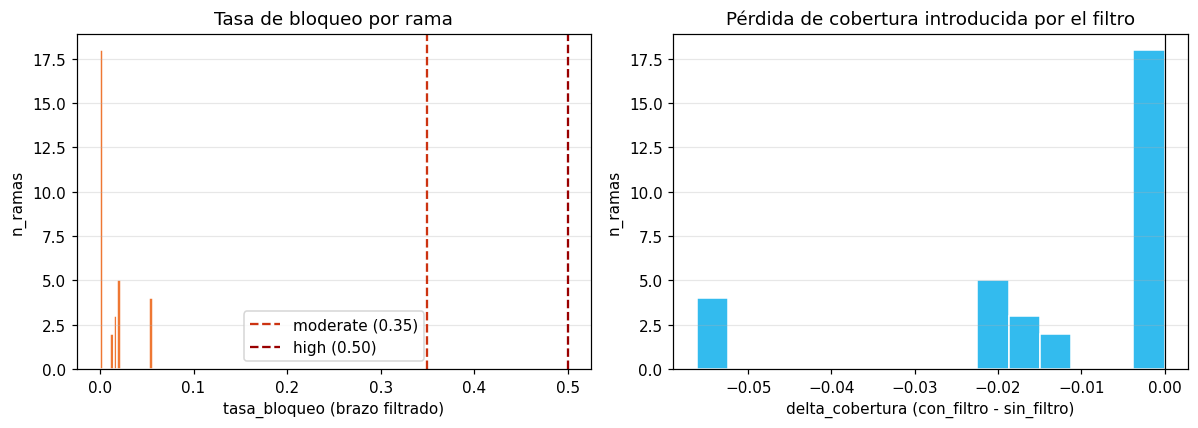

Bloqueo y cobertura


,valor
n_ramas,32.00000
mediana_tasa_bloqueo,0.00000
maxima_tasa_bloqueo,0.05618
n_bloqueo_sobre_5pct,4.00000
n_bloqueo_sobre_moderado_0_35,0.00000
mediana_delta_cobertura,0.00000


In [5]:
blocked = post['blocked_trade_rate'].astype(float)
coverage_delta = post['delta_coverage'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(blocked.values, bins=15, color='#EE7733', edgecolor='white')
axes[0].axvline(0.35, color='#CC3311', linestyle='--', label='moderate (0.35)')
axes[0].axvline(0.50, color='#990000', linestyle='--', label='high (0.50)')
axes[0].set_xlabel('tasa_bloqueo (brazo filtrado)')
axes[0].set_ylabel('n_ramas')
axes[0].set_title('Tasa de bloqueo por rama')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(coverage_delta.values, bins=15, color='#33BBEE', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('delta_cobertura (con_filtro - sin_filtro)')
axes[1].set_ylabel('n_ramas')
axes[1].set_title('Pérdida de cobertura introducida por el filtro')
axes[1].grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'post_experiment_blocked_and_coverage.png')
plt.show()

stats = {
    'n_ramas': int(len(post)),
    'mediana_tasa_bloqueo': float(blocked.median()),
    'maxima_tasa_bloqueo': float(blocked.max()),
    'n_bloqueo_sobre_5pct': int((blocked > 0.05).sum()),
    'n_bloqueo_sobre_moderado_0_35': int((blocked >= 0.35).sum()),
    'mediana_delta_cobertura': float(coverage_delta.median()),
}
pd.DataFrame([stats]).to_csv(FIG_DIR / 'post_experiment_blocked_stats.csv', index=False)
print('Bloqueo y cobertura')
display(pd.DataFrame([stats]).T.rename(columns={0: 'valor'}))

## 5. Mapa de aceptación por símbolo × método

Número de ramas aceptadas (`is_accepted = True`) por celda (sin distinguir familia ni inyección). Cada celda tiene entre 1 y varias ramas en el panel Exp2.

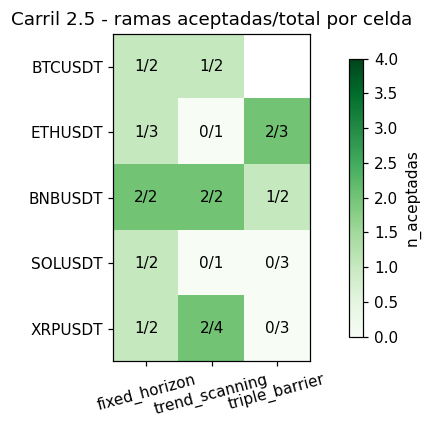

In [6]:
post['accepted_int'] = post['is_accepted'].map({True: 1.0, False: 0.0})
accept_pivot = (
    post.pivot_table(
        index='symbol', columns='method',
        values='accepted_int', aggfunc='sum',
    )
    .reindex(['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT'])
    .reindex(columns=['fixed_horizon', 'trend_scanning', 'triple_barrier'])
)
branches_pivot = (
    post.pivot_table(
        index='symbol', columns='method',
        values='study_id', aggfunc='count',
    )
    .reindex(accept_pivot.index)
    .reindex(columns=accept_pivot.columns)
)
accept_pivot.to_csv(FIG_DIR / 'post_experiment_acceptance_pivot.csv')
branches_pivot.to_csv(FIG_DIR / 'post_experiment_branches_pivot.csv')

accept_arr = np.asarray(accept_pivot.values, dtype='float64')
branches_arr = np.asarray(branches_pivot.values, dtype='float64')
vmax_heat = float(np.nanmax(branches_arr)) if np.isfinite(np.nanmax(branches_arr)) else 1.0
vmax_heat = max(1.0, vmax_heat)

fig, ax = plt.subplots(figsize=(7.5, 4))
im = ax.imshow(accept_arr, cmap='Greens', vmin=0, vmax=vmax_heat)
ax.set_xticks(range(len(accept_pivot.columns)))
ax.set_xticklabels(accept_pivot.columns, rotation=15)
ax.set_yticks(range(len(accept_pivot.index)))
ax.set_yticklabels(accept_pivot.index)
ax.set_title('Carril 2.5 - ramas aceptadas/total por celda')
for i in range(accept_pivot.shape[0]):
    for j in range(accept_pivot.shape[1]):
        acc = accept_arr[i, j]
        tot = branches_arr[i, j]
        if np.isfinite(tot):
            acc_int = int(acc) if np.isfinite(acc) else 0
            txt = f'{acc_int}/{int(tot)}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=10, color='black')
fig.colorbar(im, ax=ax, shrink=0.85, label='n_aceptadas')
fig.tight_layout()
fig.savefig(FIG_DIR / 'post_experiment_acceptance_heatmap.png')
plt.show()

## 6. Comparación de políticas de *sizing* (`fixed_control` vs `vol_target`)

Compara el **Sharpe agregado** producido por cada política de *sizing* aplicada sobre la señal filtrada. En esta ejecución no hay dominancia clara: `vol_target` solo sería preferible si mejorase de forma suficientemente consistente al baseline `fixed_control`, no por victorias puntuales aisladas.

Estadísticos sizing (vol_target - fixed_control) en Sharpe agregado


,valor
n_ramas,32.000000
n_vt_supera_fc,15.000000
n_fc_supera_vt,17.000000
mediana_delta,-0.000445
media_delta,-0.001413


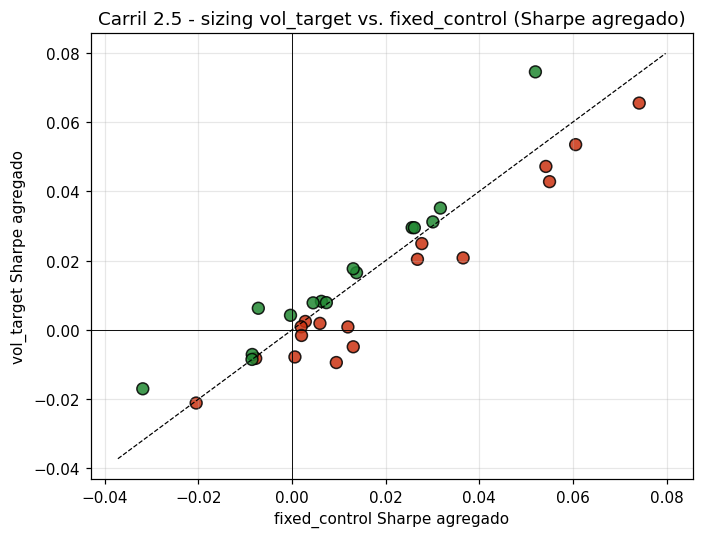

In [7]:
sizing_df = post.dropna(subset=['fixed_control_sharpe', 'vol_target_sharpe']).copy()
sizing_df['delta_vt_minus_fc_sharpe'] = (
    sizing_df['vol_target_sharpe'].astype(float)
    - sizing_df['fixed_control_sharpe'].astype(float)
)
sizing_export = sizing_df[['study_id', 'symbol', 'method', 'family',
                           'fixed_control_sharpe', 'vol_target_sharpe',
                           'delta_vt_minus_fc_sharpe']]
a_es(sizing_export).to_csv(FIG_DIR / 'post_experiment_sizing_comparison.csv', index=False)

stats = {
    'n_ramas': int(len(sizing_df)),
    'n_vt_supera_fc': int((sizing_df['delta_vt_minus_fc_sharpe'] > 0).sum()),
    'n_fc_supera_vt': int((sizing_df['delta_vt_minus_fc_sharpe'] < 0).sum()),
    'mediana_delta': float(sizing_df['delta_vt_minus_fc_sharpe'].median()),
    'media_delta': float(sizing_df['delta_vt_minus_fc_sharpe'].mean()),
}
pd.DataFrame([stats]).to_csv(FIG_DIR / 'post_experiment_sizing_stats.csv', index=False)
print('Estadísticos sizing (vol_target - fixed_control) en Sharpe agregado')
display(pd.DataFrame([stats]).T.rename(columns={0: 'valor'}))

fig, ax = plt.subplots(figsize=(6.5, 5))
fc = sizing_df['fixed_control_sharpe'].astype(float)
vt = sizing_df['vol_target_sharpe'].astype(float)
colors = ['#228833' if v > 0 else '#CC3311' if v < 0 else '#888888'
          for v in sizing_df['delta_vt_minus_fc_sharpe']]
ax.scatter(fc, vt, c=colors, edgecolor='black', s=60, alpha=0.85)
lim_lo = float(min(fc.min(), vt.min(), 0.0))
lim_hi = float(max(fc.max(), vt.max(), 0.01))
pad = max((lim_hi - lim_lo) * 0.05, 0.005)
ax.plot([lim_lo - pad, lim_hi + pad], [lim_lo - pad, lim_hi + pad],
        color='black', linestyle='--', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('fixed_control Sharpe agregado')
ax.set_ylabel('vol_target Sharpe agregado')
ax.set_title('Carril 2.5 - sizing vol_target vs. fixed_control (Sharpe agregado)')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'post_experiment_sizing_scatter.png')
plt.show()

## 7. Efecto del filtro EVT/CVaR sobre el MaxDD primario (mediana entre folds)

La métrica de *drawdown* defendible en este carril es la **mediana del MaxDD entre *outer folds*** (`ctrl_max_drawdown_fold_median` / `filt_max_drawdown_fold_median`), no el MaxDD sobre la serie concatenada de folds (artefacto metodológico; las columnas agregadas permanecen solo en la tabla de la sección 1).

Comparativa **brazo filtrado vs. control** por rama, en paralelo a la sección 3 para Sharpe: un delta positivo (`filt - ctrl`) indica un drawdown típico por fold menos profundo tras el filtro. En esta corrida: **9** ramas mejoran, **0** empeoran y **23** quedan neutras (sin cambio en mediana fold).


Estadísticos del delta MaxDD fold (filtrado - control; positivo = drawdown menos profundo)


,valor
n_ramas,32.000000
n_mejoradas,9.000000
n_empeoradas,0.000000
n_neutrales,23.000000
media_delta,0.002511
mediana_delta,0.000000
minimo_delta,0.000000
maximo_delta,0.028516


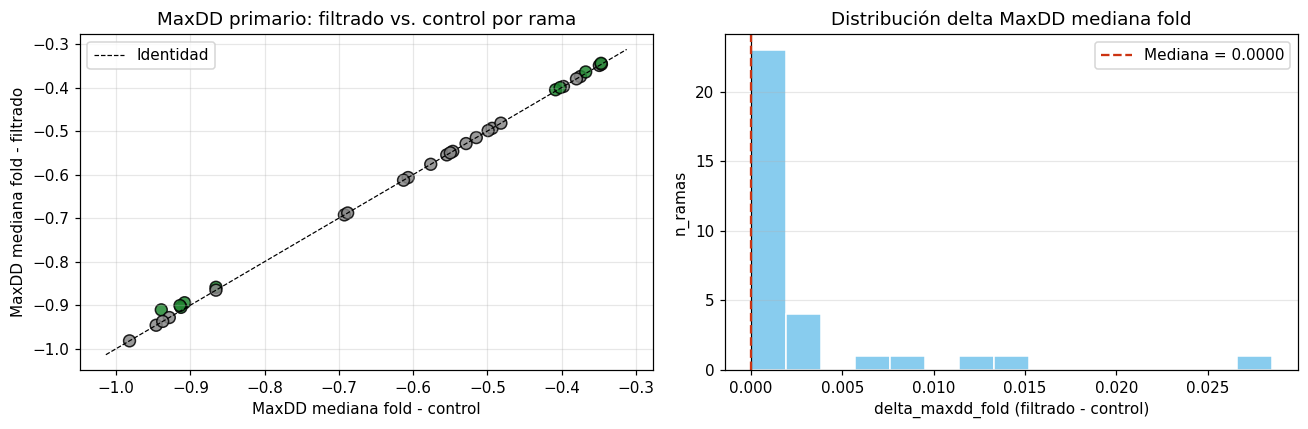

In [8]:
post_maxdd = post.dropna(
    subset=['ctrl_max_drawdown_fold_median', 'filt_max_drawdown_fold_median']
).copy()
for col in ('ctrl_max_drawdown_fold_median', 'filt_max_drawdown_fold_median'):
    post_maxdd[col] = pd.to_numeric(post_maxdd[col], errors='coerce')

post_maxdd['delta_maxdd_fold'] = (
    post_maxdd['filt_max_drawdown_fold_median'] - post_maxdd['ctrl_max_drawdown_fold_median']
)

delta_maxdd_stats = {
    'n_ramas': int(len(post_maxdd)),
    'n_mejoradas': int((post_maxdd['delta_maxdd_fold'] > 0).sum()),
    'n_empeoradas': int((post_maxdd['delta_maxdd_fold'] < 0).sum()),
    'n_neutrales': int((post_maxdd['delta_maxdd_fold'] == 0).sum()),
    'media_delta': float(post_maxdd['delta_maxdd_fold'].mean()),
    'mediana_delta': float(post_maxdd['delta_maxdd_fold'].median()),
    'minimo_delta': float(post_maxdd['delta_maxdd_fold'].min()),
    'maximo_delta': float(post_maxdd['delta_maxdd_fold'].max()),
}
pd.DataFrame([delta_maxdd_stats]).to_csv(
    FIG_DIR / 'post_experiment_delta_maxdd_fold_stats.csv', index=False
)

export_cols = [
    'symbol', 'method', 'family',
    'ctrl_max_drawdown_fold_median', 'filt_max_drawdown_fold_median', 'delta_maxdd_fold',
]
a_es(post_maxdd[export_cols]).to_csv(
    FIG_DIR / 'post_experiment_maxdd_fold_comparison.csv', index=False
)

print('Estadísticos del delta MaxDD fold (filtrado - control; positivo = drawdown menos profundo)')
display(pd.DataFrame([delta_maxdd_stats]).T.rename(columns={0: 'valor'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.scatter(
    post_maxdd['ctrl_max_drawdown_fold_median'],
    post_maxdd['filt_max_drawdown_fold_median'],
    c=['#228833' if v > 0 else '#CC3311' if v < 0 else '#888888'
       for v in post_maxdd['delta_maxdd_fold']],
    edgecolor='black', s=60, alpha=0.85,
)
lo = float(post_maxdd[['ctrl_max_drawdown_fold_median', 'filt_max_drawdown_fold_median']].min().min())
hi = float(post_maxdd[['ctrl_max_drawdown_fold_median', 'filt_max_drawdown_fold_median']].max().max())
pad = max((hi - lo) * 0.05, 0.005)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
        color='black', linestyle='--', linewidth=0.8, label='Identidad')
ax.set_xlabel('MaxDD mediana fold - control')
ax.set_ylabel('MaxDD mediana fold - filtrado')
ax.set_title('MaxDD primario: filtrado vs. control por rama')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(post_maxdd['delta_maxdd_fold'].values, bins=15,
        color='#88CCEE', edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(
    post_maxdd['delta_maxdd_fold'].median(), color='#CC3311', linestyle='--',
    label=f'Mediana = {post_maxdd["delta_maxdd_fold"].median():.4f}',
)
ax.set_xlabel('delta_maxdd_fold (filtrado - control)')
ax.set_ylabel('n_ramas')
ax.set_title('Distribución delta MaxDD mediana fold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'post_experiment_delta_maxdd_fold.png')
plt.show()


## 8. DSR deflactado del brazo filtrado (N total por celda)

Métrica de **multiplicidad de hipótesis** al cierre del carril: *Deflated Sharpe Ratio* del brazo **filtrado**, calculado desde retornos OOS reales y deflactando por **N_total = N_exp1 + N_exp2 + 2** en la celda `(símbolo, método)`. Fuente: `scripts/recompute_dsr_post_experiment_total.py` -> `reports/validation/dsr_exact/dsr_exact_post_experiment_supervised.csv`.

**Lectura:** solo cuenta el **DSR recalculado** frente al umbral 0.95 (misma convención que el sub-gate `retains_significant_dsr` de la sección 2, pero con N coherente). El DSR que la pipeline escribe en el JSON del gate **no se usa aquí**: sirve como lectura local del paso 2.5, no como cierre de multiplicidad.

**Salida en pantalla:** tabla resumen del brazo filtrado; top 5 ramas por DSR; histograma con umbral 0.95. El detalle fila a fila queda en `post_experiment_dsr_filtered_table.csv`.

**Gráfico:** histograma del DSR recalculado en las 32 ramas del brazo filtrado. La economía primaria del paso sigue en Sharpe y MaxDD por fold (secciones 3 y 7).


DSR brazo filtrado (umbral 0.95)


,valor
n_ramas_filtrado,3.200000e+01
n_ramas_dsr_ge_095,0.000000e+00
mediana_dsr,8.683478e-04
maximo_dsr,9.207901e-01
minimo_dsr,5.180555e-51
mediana_n_trials_total,4.200000e+01


Top 5 ramas por DSR filtrado


,simbolo,metodo,familia,arquitectura_paquete,sharpe_observado,n_trials_total,dsr_filtrado,dsr_supera_0_95
0,BTCUSDT,trend_scanning,lstm,none/core_only,0.0520,38,0.9208,False
1,BNBUSDT,fixed_horizon,residual_hybrid,staged/onchain,0.0550,38,0.7421,False
2,BNBUSDT,fixed_horizon,residual_hybrid,monolithic/core_only,0.0542,38,0.7064,False
3,ETHUSDT,triple_barrier,residual_hybrid,staged/attention,0.0268,46,0.3498,False
4,BNBUSDT,triple_barrier,residual_hybrid,staged/core_only,0.0257,38,0.1657,False


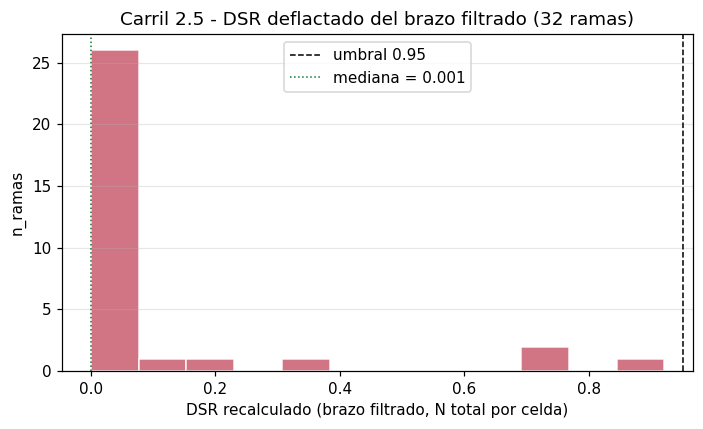

In [9]:
VALIDATION_ROOT = ROOT / 'reports' / 'validation'
dsr_exact = load_dsr_exact_post_experiment_table(VALIDATION_ROOT, track='supervised')
DSR_UMBRAL = 0.95

if dsr_exact.empty:
    print(
        'No se encontró reports/validation/dsr_exact/dsr_exact_post_experiment_supervised.csv. '
        'Ejecuta primero scripts/recompute_dsr_post_experiment_total.py --track supervised.'
    )
else:
    filt = dsr_exact[dsr_exact['arm'] == 'filtered'].copy()
    filt['dsr_exact'] = pd.to_numeric(filt['dsr_exact'], errors='coerce')
    filt = filt.dropna(subset=['dsr_exact'])

    cols_show = [
        'symbol', 'method', 'family', 'arch_pack',
        'observed_sr', 'n_trials_total', 'dsr_exact', 'is_significant_dsr',
    ]
    cols_show = [c for c in cols_show if c in filt.columns]
    filt_sorted = filt.sort_values('dsr_exact', ascending=False).reset_index(drop=True)

    vista = a_es(filt_sorted[cols_show])
    vista.to_csv(FIG_DIR / 'post_experiment_dsr_filtered_table.csv', index=False)

    n_sig = int((filt['dsr_exact'] >= DSR_UMBRAL).sum())
    dsr_summary = {
        'n_ramas_filtrado': int(len(filt)),
        'n_ramas_dsr_ge_095': n_sig,
        'mediana_dsr': float(filt['dsr_exact'].median()),
        'maximo_dsr': float(filt['dsr_exact'].max()),
        'minimo_dsr': float(filt['dsr_exact'].min()),
        'mediana_n_trials_total': float(filt['n_trials_total'].median()),
    }
    pd.DataFrame([dsr_summary]).to_csv(
        FIG_DIR / 'post_experiment_dsr_summary_stats.csv', index=False
    )
    print(f'DSR brazo filtrado (umbral {DSR_UMBRAL})')
    display(pd.DataFrame([dsr_summary]).T.rename(columns={0: 'valor'}))
    print('Top 5 ramas por DSR filtrado')
    display(vista.head(5).round(4))

    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.hist(
        filt['dsr_exact'].values, bins=12,
        color='#CC6677', edgecolor='white', alpha=0.9,
    )
    ax.axvline(
        DSR_UMBRAL, color='black', linewidth=1.0, linestyle='--',
        label=f'umbral {DSR_UMBRAL}',
    )
    ax.axvline(
        filt['dsr_exact'].median(), color='#117733', linewidth=1.0, linestyle=':',
        label=f'mediana = {filt["dsr_exact"].median():.3f}',
    )
    ax.set_xlabel('DSR recalculado (brazo filtrado, N total por celda)')
    ax.set_ylabel('n_ramas')
    ax.set_title('Carril 2.5 - DSR deflactado del brazo filtrado (32 ramas)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'post_experiment_dsr_filtered_hist.png')
    plt.show()


## 9. Conclusiones

Lectura primaria sobre **Sharpe agregado** y **mediana del MaxDD entre *outer folds*** (valores de la última ejecución del notebook):

- **Cobertura:** 32/32 reportes (`orchestrator_summary.json` con `n_success = 32`).
- **Sharpe:** mediana del `delta_sharpe` (filtrado - control) ≈ 0 (4 ramas mejoran, 10 empeoran, 18 neutras). El filtro EVT/CVaR **no actúa como palanca sistemática de alpha**; su rol es **gobernanza de cola**.
- **MaxDD por fold:** 9 ramas con mejora (delta fold > 0), 23 neutras, 0 empeoran; entre las **14** ramas con bloqueo > 0, **9** mejoran la mediana fold (las 18 neutras en Sharpe suelen coincidir con bloqueo nulo).
- **Bloqueo/cobertura:** mediana de `blocked_trade_rate` = 0; máximo 5.6 %; 28/32 ramas por debajo del 5 %.
- **Sizing:** `vol_target` mejora el Sharpe agregado en 15/32 ramas y `fixed_control` lo hace en 17/32; no hay dominancia clara y la mediana del delta (`vol_target - fixed_control`) queda ligeramente negativa, así que `fixed_control` sigue siendo el baseline más estable.

Lectura diagnóstica (gate `execution_risk_two_arm_acceptance`):

- **Defensivo** (`reduces_drawdown_or_cvar`): **32/32** ramas pasan (operador OR).
- **`retains_significant_dsr` (JSON):** **14/32** ramas pasan el sub-gate; en la **sección 8**, con DSR recalculado y N total, **0/32** brazos filtrados alcanzan DSR ≥ 0.95 (máximo observado 0.92).
- **`is_accepted`:** **14/32** ramas; en muchas el delta Sharpe es nulo cuando el filtro no bloquea (coherente con gobernanza sin reescalar alpha).

**Lectura:** el carril 2.5 es **gobernanza** sobre la señal congelada, no amplificador de *alpha*. Métricas primarias: Sharpe agregado y MaxDD por fold (secciones 3 y 7); DSR recalculado del brazo filtrado (sección 8) como cierre de multiplicidad.

**Artefactos persistidos (citables en la memoria):**

- `reports/figures/exp_synthesis/post_experiment/post_experiment_raw.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_acceptance_breakdown.png`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_acceptance_counts.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_delta_sharpe.png`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_delta_sharpe_stats.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_blocked_and_coverage.png`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_blocked_stats.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_acceptance_heatmap.png`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_acceptance_pivot.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_branches_pivot.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_sizing_scatter.png`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_sizing_comparison.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_sizing_stats.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_maxdd_fold_comparison.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_delta_maxdd_fold.png`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_delta_maxdd_fold_stats.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_dsr_filtered_table.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_dsr_summary_stats.csv`
- `reports/figures/exp_synthesis/post_experiment/post_experiment_dsr_filtered_hist.png`
- `reports/validation/dsr_exact/dsr_exact_post_experiment_supervised.csv`
